<script type="text/javascript" src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML"></script>
# Part A: Three decompositions of a one-dimensional signal

# Introduction

This part introduces the three frequency-domain tools we will use throughout the assignment:

1. **Discrete Fourier Transform (DFT)** — global frequency content.
2. **Short-Time Fourier Transform (STFT)** — frequency content as a function of time, at a fixed resolution.
3. **Continuous Wavelet Transform (CWT)** — frequency content as a function of time, at adaptive resolution.

The signal we analyze contains a stationary background sinusoid plus two short, localized pulses. Each transform reveals a different aspect of it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Building the signal

A **stationary sinusoid** is a pure tone that lives across the entire time window:

$$s(t) = A_s \, \sin(2\pi f_s \, t)$$

A **wave packet** (or "pulse") is a sinusoid multiplied by a Gaussian envelope, localized in time around $t_0$ with width $w$:

$$p(t; t_0, f, w, A) = A \, e^{-(t - t_0)^2 / (2 w^2)} \, \sin(2\pi f \, (t - t_0))$$

Our signal is the sum of one stationary sinusoid and two wave packets:

$$x(t) = s(t) + p_1(t) + p_2(t)$$

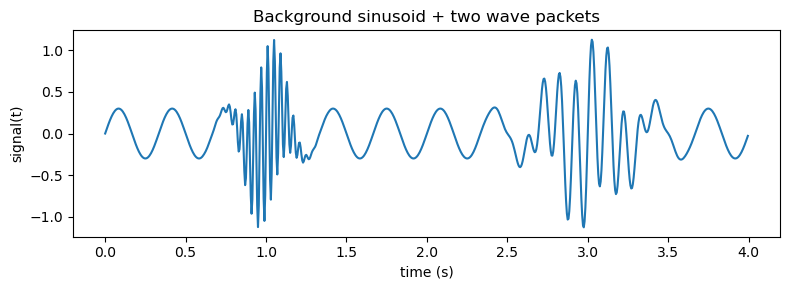

In [6]:
sampling_rate = 200.0
duration = 4.0
time_values = np.arange(0.0, duration, 1.0 / sampling_rate)
 
 
def stationary_sine(times, freq, amplitude=1.0):
    """A pure sinusoid spanning the entire time axis."""
    return amplitude * np.sin(2.0 * np.pi * freq * times)
 
 
def wave_packet(times, center, freq, width, amplitude=1.0):
    """A Gaussian-modulated sinusoid centered at `center` with envelope width `width`."""
    envelope = np.exp(-0.5 * ((times - center) / width) ** 2)
    carrier = np.sin(2.0 * np.pi * freq * (times - center))
    return amplitude * envelope * carrier
 
 
# Signal parameters — feel free to change these in the tasks below.
background_freq = 3.0       # Hz, the stationary sinusoid
background_amplitude = 0.3
 
pulse1_center, pulse1_freq, pulse1_width = 3, 10.0, 0.2
pulse2_center, pulse2_freq, pulse2_width = 1, 25.0, 0.1
 
signal = (
    background_amplitude * np.sin(2.0 * np.pi * background_freq * time_values)
    + wave_packet(time_values, pulse1_center, pulse1_freq, pulse1_width)
    + wave_packet(time_values, pulse2_center, pulse2_freq, pulse2_width)
)
 
plt.figure(figsize=(8, 3))
plt.plot(time_values, signal)
plt.xlabel("time (s)"); plt.ylabel("signal(t)")
plt.title("Background sinusoid + two wave packets")
plt.tight_layout()
plt.show()

# The Discrete Fourier Transform

The DFT projects a signal onto a basis of complex exponentials. For an input of length $N$ sampled uniformly,

$$X_k = \sum_{n=0}^{N-1} x_n \, e^{-i\, 2\pi k n / N}, \qquad k = 0, 1, \ldots, N - 1.$$

Each coefficient $X_k$ is the inner product of the signal with the $k$-th sinusoid; its magnitude $|X_k|$ tells us how much of that frequency is present, and its phase tells us where in time it sits.

<div class="alert alert-warning">
    <h3>Task A.1: Implementing the DFT</h3>
    Implement <code>naive_dft(signal)</code> from the definition above. Verify that your implementation agrees with <code>np.fft.fft</code> to numerical precision, then plot the magnitude spectrum.
</div>

Max abs diff vs np.fft.fft: 3.05e-11


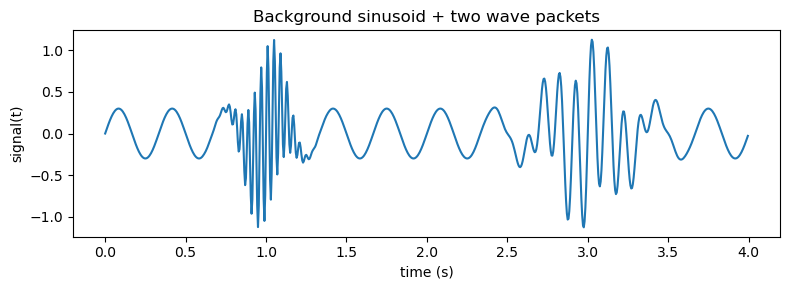

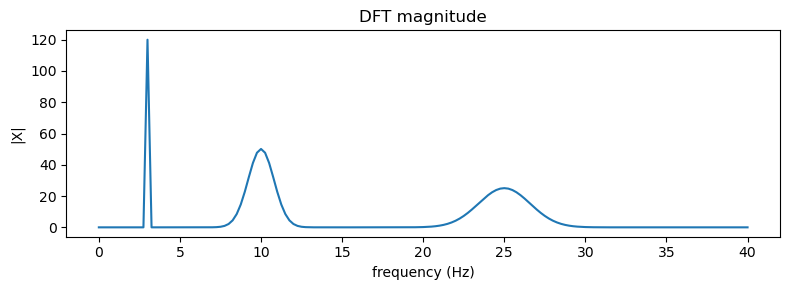

In [4]:
def naive_dft(signal):
    ### BEGIN SOLUTION

    signal = np.asarray(signal, dtype=complex)
    N = signal.size
    
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    exponent_matrix = np.exp(-2j * np.pi * k * n / N)
    
    return exponent_matrix @ signal
    
    ### END SOLUTION


spectrum_naive = naive_dft(signal)
spectrum_fft   = np.fft.fft(signal)
print(f"Max abs diff vs np.fft.fft: {np.max(np.abs(spectrum_naive - spectrum_fft)):.2e}")

# Plot only the non-redundant positive frequencies up to a sensible upper limit.
freqs = np.fft.fftfreq(signal.size, d=1.0 / sampling_rate)
mask = (freqs >= 0) & (freqs <= 40)

plt.figure(figsize=(8, 3))
plt.plot(time_values, signal)
plt.xlabel("time (s)"); plt.ylabel("signal(t)")
plt.title("Background sinusoid + two wave packets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(freqs[mask], np.abs(spectrum_naive[mask]))
plt.xlabel("frequency (Hz)"); plt.ylabel("|X|")
plt.title("DFT magnitude")
plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h3>Task A.2: Playing with the signal</h3>
    Re-run the signal-construction cell and the DFT cell with the following modifications, one at a time, and observe how the spectrum changes:
    <ol>
        <li><b>Stationary wave only</b> Remove all waves but the stationary one</li>
        <li><b>Turn off the stationary wave</b> Set the amplitude of the background stationary wave to zero.</li>
        <li><b>Wider pulses.</b> Recover the wave packets, set <code>pulse1_width = 0.6</code>, and <code>pulse2_width = 0.05</code>.</li>
    </ol>
    Then answer:
    <ol>
        <li>With only the stationary background present, what do you see? Why does a stationary sinusoid produce a sharper spectral feature than a finite-duration pulse? </li>
        <li>Compare the spectrum of the wider pulse (<code>pulse1_width = 0.6</code>) with the spectrum of the narrower one (<code>pulse2_width = 0.05</code>). Which produces a wider bump in frequency? Why?</li>
    </ol>
</div>

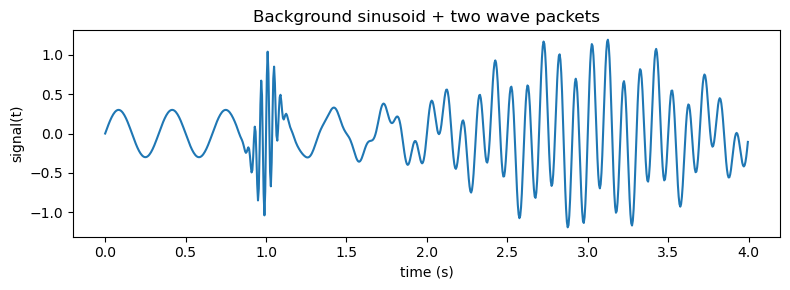

In [8]:
background_freq = 3.0
background_amplitude = 0.3
 
pulse1_center, pulse1_freq, pulse1_width = 3, 10.0, 0.6
pulse2_center, pulse2_freq, pulse2_width = 1, 25.0, 0.05
 
signal = (
    background_amplitude * np.sin(2.0 * np.pi * background_freq * time_values)
    + wave_packet(time_values, pulse1_center, pulse1_freq, pulse1_width)
    + wave_packet(time_values, pulse2_center, pulse2_freq, pulse2_width)
)
 
plt.figure(figsize=(8, 3))
plt.plot(time_values, signal)
plt.xlabel("time (s)"); plt.ylabel("signal(t)")
plt.title("Background sinusoid + two wave packets")
plt.tight_layout()
plt.show()

**Answers here**

# The Short-Time Fourier Transform

The DFT tells us *which* frequencies are present, but discards *when* each one occurred. The fix is to slide a short window across the signal, take the DFT of each windowed segment, and stack the results into a 2D image: frequency on one axis, time on the other. This is the window Fourier Transform shown in the lecture, also known as **Short-Time Fourier Transform**:

$$\mathrm{STFT}\{\text{signal}\}(k, m) = \sum_{n=0}^{W-1} \text{signal}_{n + m H} \, w_n \, e^{-i\, 2\pi k n / W}$$

where $W$ is the window length, $H$ is the *hop* between successive frames, and $w_n$ is the **window function**.

**Why a window function?** Cutting out a segment of the signal with a hard rectangular cut introduces sharp edges that produce spurious high-frequency content in the per-frame DFT. A smooth window (e.g. Hann) tapers the segment to zero at both ends, suppressing those edge artifacts.

The **Hann window** of length $W$ is:

$$w_n = \tfrac{1}{2}\left(1 - \cos\!\left(\frac{2\pi n}{W - 1}\right)\right), \qquad n = 0, 1, \ldots, W - 1.$$

For the STFT experiments below, we drop the stationary background and work with just the two wave packets — a single horizontal stripe everywhere in every spectrogram would only crowd the figures.

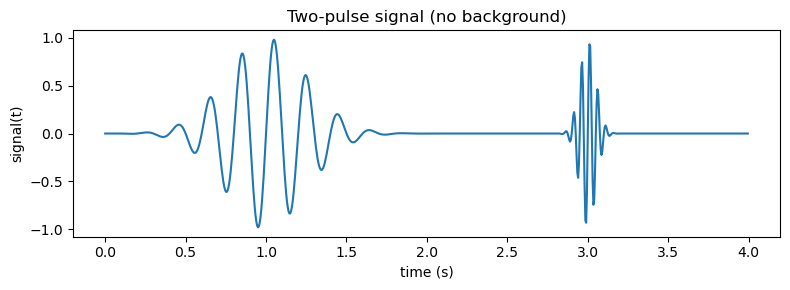

In [9]:
pulse1_center, pulse2_center = 1, 3
pulse1_freq, pulse2_freq = 5, 20
pulse1_width, pulse2_width = 0.25, 0.05
two_pulse_signal = (
    wave_packet(time_values, pulse1_center, pulse1_freq, pulse1_width)
    + wave_packet(time_values, pulse2_center, pulse2_freq, pulse2_width)
)

plt.figure(figsize=(8, 3))
plt.plot(time_values, two_pulse_signal)
plt.xlabel("time (s)"); plt.ylabel("signal(t)")
plt.title("Two-pulse signal (no background)")
plt.tight_layout(); plt.show()

<div class="alert alert-warning">
    <h3>Task A.3: Implement the Hann window and the STFT</h3>
    Implement two functions:
    <ol>
        <li><code>hann_window(window_length)</code>: return the Hann window of length <code>window_length</code> as a 1D numpy array.</li>
        <li><code>stft(signal, window, hop)</code>: slide <code>window</code> across <code>signal</code> in steps of <code>hop</code> samples, multiply, take the real FFT (<code>np.fft.rfft</code>), return a 2D array of shape <code>(n_freqs, n_frames)</code>.</li>
    </ol>
</div>

In [10]:
def hann_window(window_length):
    ### BEGIN SOLUTION

    n = np.arange(window_length)
    window = 0.5 * (1.0 - np.cos(2.0 * np.pi * n / (window_length - 1)))
    return window
    
    ### END SOLUTION


def stft(signal, window, hop):
    ### BEGIN SOLUTION
    
    signal = np.asarray(signal)
    window = np.asarray(window)
    
    window_length = window.size
    n_frames = 1 + (signal.size - window_length) // hop
    
    spectra = []
    
    for frame_idx in range(n_frames):
        start = frame_idx * hop
        end = start + window_length
        
        segment = signal[start:end]
        windowed_segment = segment * window
        
        spectrum = np.fft.rfft(windowed_segment)
        spectra.append(spectrum)
    
    return np.array(spectra).T

    ### END SOLUTION

Apply the STFT at three different window lengths.

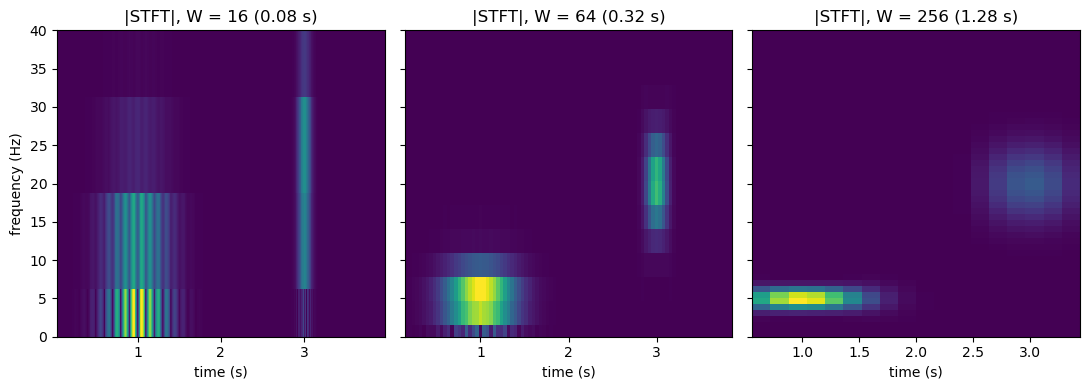

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for ax, window_length in zip(axes, [16, 64, 256]):
    window = hann_window(window_length)
    hop = max(1, window_length // 8)
    spectrogram = stft(two_pulse_signal, window, hop)

    n_frames = spectrogram.shape[1]
    frame_times = (np.arange(n_frames) * hop + window_length / 2) / sampling_rate
    frame_freqs = np.fft.rfftfreq(window_length, d=1.0 / sampling_rate)

    ax.pcolormesh(frame_times, frame_freqs, np.abs(spectrogram), shading="auto")
    ax.set_title(f"|STFT|, W = {window_length} ({window_length/sampling_rate:.2f} s)")
    ax.set_xlabel("time (s)"); ax.set_ylim(0, 40)
axes[0].set_ylabel("frequency (Hz)")
plt.tight_layout(); plt.show()

<div class="alert alert-info">
    <h3>The time-frequency uncertainty principle</h3>
    The three spectrograms tell the same story at three different settings:
    <ul>
        <li><b>Short window (W = 16):</b> the pulses appear at sharply defined times, but each one is smeared across a wide range of frequencies. The 25 Hz and 10 Hz carriers are barely distinguishable in frequency.</li>
        <li><b>Long window (W = 256):</b> the carriers are resolved cleanly in frequency, but each pulse blurs into a wide horizontal smear in time — you can no longer pinpoint when it occurred.</li>
        <li><b>Middle window (W = 64):</b> both axes are reasonable but neither is sharp.</li>
    </ul>
    This is the <b>Heisenberg uncertainty principle</b> for time-frequency analysis: for any signal, the product of its time spread $\sigma_t$ and frequency spread $\sigma_\omega$ is bounded below,
    $$\sigma_t \, \sigma_\omega \geq \tfrac{1}{2},$$
    with equality only for Gaussians. The STFT inherits this bound through its window: a shorter window has smaller $\sigma_t$ and (necessarily) larger $\sigma_\omega$, and vice versa.
</div>

<div class="alert alert-warning">
    <h3>Task A.4: Translation and the STFT</h3>
    Build a second two-pulse signal where both pulses are shifted later in time by 0.5 s. Compute its STFT spectrogram (using <code>window_length = 64</code>) and plot it next to the spectrogram of the original signal.
    <br><br>
    Then answer:
    <ol>
        <li>How does the spectrogram of the shifted signal differ from the original?</li>
        <li>Given the same input transformation, a shift on the signal, does the previous DFT lead to the same change on the output?</li>
    </ol>
</div>

**Answers here**

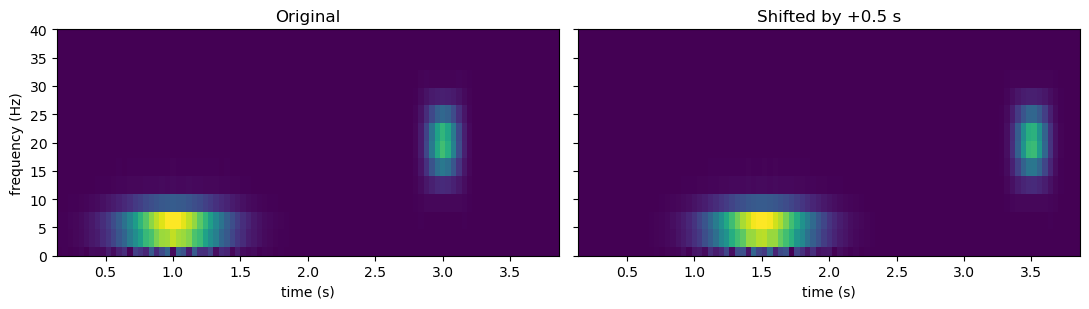

In [12]:
pulse1_center, pulse2_center = 1, 3
pulse1_freq, pulse2_freq = 5, 20
pulse1_width, pulse2_width = 0.25, 0.05
shift = 0.5
shifted_signal = (
    wave_packet(time_values, pulse1_center + shift, pulse1_freq, pulse1_width)
    + wave_packet(time_values, pulse2_center + shift, pulse2_freq, pulse2_width)
)
window_length = 64
window = hann_window(window_length)
hop = window_length // 8

spec_original = stft(two_pulse_signal, window, hop)
spec_shifted  = stft(shifted_signal,   window, hop)

n_frames = spec_original.shape[1]
frame_times = (np.arange(n_frames) * hop + window_length / 2) / sampling_rate
frame_freqs = np.fft.rfftfreq(window_length, d=1.0 / sampling_rate)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].pcolormesh(frame_times, frame_freqs, np.abs(spec_original), shading="auto")
axes[0].set_title("Original")
axes[1].pcolormesh(frame_times, frame_freqs, np.abs(spec_shifted), shading="auto")
axes[1].set_title("Shifted by +0.5 s")
for ax in axes:
    ax.set_xlabel("time (s)"); ax.set_ylim(0, 40)
axes[0].set_ylabel("frequency (Hz)")
plt.tight_layout(); plt.show()

# Bonus: How the FFT works

Computing the DFT from the definition costs $O(N^2)$ operations: $N$ output coefficients, each summing $N$ terms. For a signal of length $N = 10^6$, that's $10^{12}$ multiplications — many minutes of compute for a single transform. The Fast Fourier Transform reduces this to $O(N \log N)$.

Let's see where the speedup comes from.

<div class="alert alert-info">
    <h3>The Cooley-Tukey trick</h3>
    The DFT of a length-$N$ signal can be split into two DFTs of length $N/2$ — one over the even-indexed samples, one over the odd-indexed samples — combined with $N$ extra multiplications and additions. Concretely, splitting $X_k = \sum_n x_n e^{-i 2\pi k n / N}$ by parity of $n$:
    $$X_k = \underbrace{\sum_{m=0}^{N/2-1} x_{2m} \, e^{-i 2\pi k m / (N/2)}}_{E_k\text{: DFT of even samples}} + e^{-i 2\pi k / N} \, \underbrace{\sum_{m=0}^{N/2-1} x_{2m+1} \, e^{-i 2\pi k m / (N/2)}}_{O_k\text{: DFT of odd samples}}$$
    <br>
    for $k = 0, \ldots, N/2 - 1$, with the second half given by symmetry: $X_{k + N/2} = E_k - e^{-i 2\pi k / N} O_k$.
    <br><br>
    The factor $e^{-i 2\pi k / N}$ is called the "twiddle factor". Two length-$N/2$ DFTs plus $N$ twiddle multiplications is much cheaper than one length-$N$ DFT. Moreover, we can apply the same trick to each of the two halves, recursively. After $\log_2 N$ levels of splitting, we are left with trivial length-1 DFTs.
</div>

<div class="alert alert-warning">
    <h3>Task A.5 (bonus): Implement one FFT step</h3>
    Implement <code>fft_one_step(signal)</code>: assume <code>signal.size</code> is even, compute the DFTs of the even-indexed and odd-indexed halves <i>using <code>np.fft.fft</code></i> (we are not yet recursing all the way down), combine them with the twiddle factors as above, and return the resulting length-$N$ DFT.
    <br><br>
    Verify that your implementation agrees with <code>np.fft.fft</code> applied directly to the full signal.
</div>

In [13]:
def fft_one_step(signal):
    ### BEGIN SOLUTION

    signal = np.asarray(signal, dtype=complex)
    N = signal.size
    
    even_spectrum = np.fft.fft(signal[::2])
    odd_spectrum = np.fft.fft(signal[1::2])
    
    k = np.arange(N // 2)
    twiddle = np.exp(-2j * np.pi * k / N)
    
    first_half = even_spectrum + twiddle * odd_spectrum
    second_half = even_spectrum - twiddle * odd_spectrum
    
    return np.concatenate([first_half, second_half])
    
    ### END SOLUTION


test_signal = np.random.randn(64)
diff = np.max(np.abs(fft_one_step(test_signal) - np.fft.fft(test_signal)))
print(f"Max abs diff: {diff:.2e}")

Max abs diff: 5.33e-15


<div class="alert alert-info">
    <h3>Why this gives O(N log N)</h3>
    One step replaces a length-$N$ DFT with two length-$N/2$ DFTs plus $O(N)$ work for the twiddles. Recursing this split a length-$N/2$ DFT becomes two length-$N/4$ DFTs plus $O(N/2)$ work, and so on — gives $\log_2 N$ levels of $O(N)$ work each. Total: $O(N \log N)$.
</div>

<div class="alert alert-warning">
    <h3>Task A.6 (bonus): Benchmark the speedup</h3>
    Time both your <code>naive_dft</code> and <code>np.fft.fft</code> on random signals of length $N \in \{2^4, 2^5, \ldots, 2^{12}\}$. Plot run-time vs. $N$ on a log-log scale. The naive curve should grow much faster than the FFT curve, with the gap widening at large $N$.
</div>

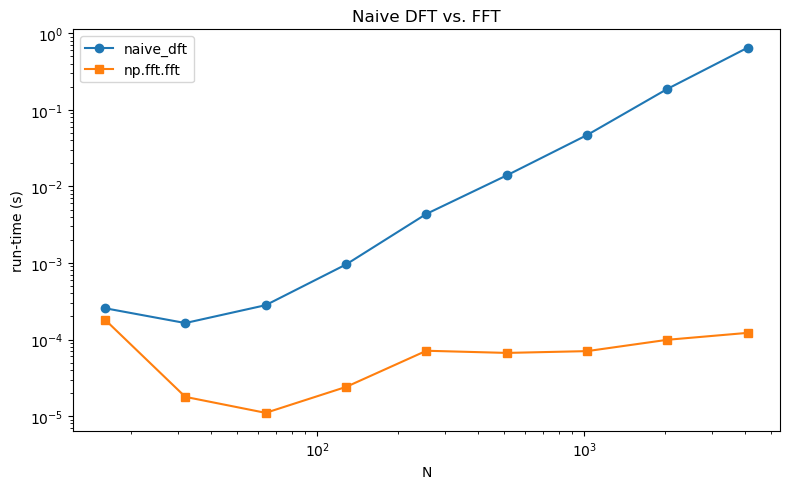

In [14]:
import time

sizes = [2 ** exponent for exponent in range(4, 13)]
times_naive, times_fft = [], []

### BEGIN SOLUTION

for N in sizes:
    test_signal = np.random.randn(N)

    start = time.perf_counter()
    naive_dft(test_signal)
    end = time.perf_counter()
    times_naive.append(end - start)

    start = time.perf_counter()
    np.fft.fft(test_signal)
    end = time.perf_counter()
    times_fft.append(end - start)

### END SOLUTION

plt.figure(figsize=(8, 5))
plt.loglog(sizes, times_naive, "o-", label="naive_dft")
plt.loglog(sizes, times_fft,   "s-", label="np.fft.fft")
plt.xlabel("N"); plt.ylabel("run-time (s)")
plt.title("Naive DFT vs. FFT")
plt.legend(); plt.tight_layout(); plt.show()

<script type="text/javascript" src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML"></script>
# Part B: Image compression with Fourier and wavelets

# Introduction

In Part A we saw that the Fourier basis is *global* (each basis function spans the whole signal) while wavelets are *local* (each is a bump confined to a small region). This part explores what that difference implies in practice, on a single image:

1. **Compression power.** If we keep only the $K$ largest coefficients and discard the rest, how does the reconstruction quality compare between the two bases?
2. **Stability of coefficients.** If a single coefficient gets corrupted, how does that error spread through the reconstructed image?

Wavelets do better on both counts for natural images, but for related and overlapping reasons. We will see both.

In [22]:
from PIL import Image
import pywt

# Wavelets in 1D

# Wavelets in 1D

A **wavelet** $\psi(t)$ is an oscillating, localized function with zero mean — a "wave packet" that integrates to zero. Starting from a single wavelet $\psi$ (the *mother wavelet*), an entire family of functions is generated by **dilation and translation**:

$$\psi_{a, b}(t) = \frac{1}{\sqrt{a}} \, \psi\!\left( \frac{t - b}{a} \right), \qquad a > 0, \; b \in \mathbb{R}.$$

Here $a$ is the *scale* and $b$ is the *translation*. The $1/\sqrt{a}$ factor preserves the L² norm:
$$\|\psi_{a, b}\|^2_2 = \int |\psi_{a, b}(t)|^2 \, dt=1.$$

<div class="alert alert-warning">
    <h3>Task B.1: Implement the Mexican hat wavelet</h3>
    The Mexican hat uses as a mother wavelet the second derivative of a Gaussian:
    $$\psi(t) = \frac{2}{\sqrt{3}\, \pi^{1/4}} \left(1 - t^2 \right) \exp\!\left(-\frac{t^2}{2}\right).$$
    Implement this wavelet as a function <code>mother_wavelet</code> and use it to generate arbitrary wavelets $\psi_{a, b}(t)$, defined in a function <code>mexican_hat(t, scale, translation)</code>. Plot the hat for different values of $a$ and $b$ and verify numerically that the norm is (almost) 1.
</div>

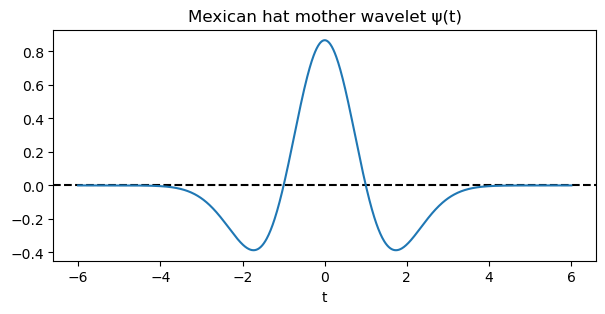

In [15]:
def mother_wavelet(t):
    ### BEGIN SOLUTION

    constant = 2.0 / (np.sqrt(3.0) * np.pi ** 0.25)
    return constant * (1.0 - t**2) * np.exp(-0.5 * t**2)
    
    ### END SOLUTION

def mexican_hat(t, scale, translation):
    ### BEGIN SOLUTION

     return (1.0 / np.sqrt(scale)) * mother_wavelet((t - translation) / scale)
    
    ### END SOLUTION

# Plot the mother wavelet
t_axis = np.linspace(-6.0, 6.0, 1000)
plt.figure(figsize=(7, 3))
plt.axhline(0, ls='--', color="k")
plt.plot(t_axis, mother_wavelet(t_axis))
plt.title("Mexican hat mother wavelet ψ(t)")
plt.xlabel("t")
plt.show()

Numerical L² norm of ψ_{a, b} for several (a, b):
(a = 1.0, b = 0.0): ||ψ_{a,b}||² = 1.0000
(a = 0.5, b = 0.0): ||ψ_{a,b}||² = 1.0000
(a = 2.0, b = 0.0): ||ψ_{a,b}||² = 0.9976
(a = 1.0, b = 2.0): ||ψ_{a,b}||² = 1.0000


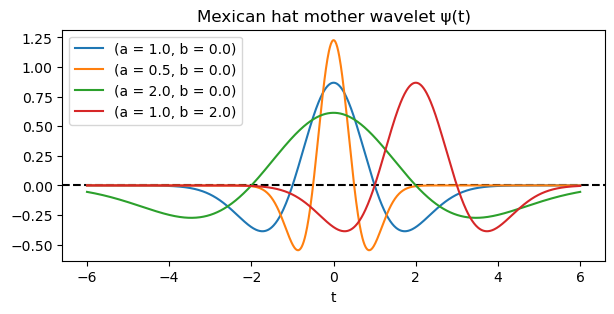

In [16]:
plt.figure(figsize=(7, 3))
plt.axhline(0, ls='--', color="k")

print("Numerical L² norm of ψ_{a, b} for several (a, b):")
for scale, translation in [(1.0, 0.0), (0.5, 0.0), (2.0, 0.0), (1.0, 2.0)]:
    psi = mexican_hat(t_axis, scale=scale, translation=translation)
    plt.plot(t_axis, psi, label=f"(a = {scale}, b = {translation})")
    
    ### BEGIN SOLUTION

    norm_squared = np.trapz(np.abs(psi) ** 2, t_axis)
    
    ### END SOLUTION
    print(f"(a = {scale}, b = {translation}): ||ψ_{{a,b}}||² = {norm_squared:.4f}")

plt.title("Mexican hat mother wavelet ψ(t)")
plt.xlabel("t")
plt.legend()
plt.show()

<div class="alert alert-warning">
    <h3>Questions B.2: Scale and Translation</h3>
    <ol>
         <li>What does increasing the scale $a$ do to the shape of the wavelet? What does increasing the translation $b$ do? </li>
         <li>Can you find analogous parameters in the Fourier basis $e^{i\omega t}$? Why?</li>
   </ol>
</div>

**Answers here**

As the scale parameter a increases, the wavelet becomes wider and lower; as the translation parameter b increases, the wavelet shifts to the right.

In the Fourier basis, there is a frequency parameter (ω), but no true translation parameter, because Fourier basis functions are distributed globally across the entire signal and are not shifted locally.

<div class="alert alert-warning">
    <h3>Task B.3: An orthonormal basis?</h3>
    The Fourier basis on a finite interval $[0, T]$ is <b>orthonormal</b>: 
    $$\langle e_{\omega_n}, e_{\omega_m} \rangle = \frac 1 T \int_0^T e^{i \omega_n t} e^{i \omega_m t}\, dt = \delta_{nm}, \qquad \omega_n = 2\pi n / T.$$
    Let's compare this to the hat wavelets we described.
    <ol>
        <li>Implement <code>inner_product(f, g, dt)</code> for real-valued functions sampled on a uniform grid: a numerical approximation to
            $$\langle f, g \rangle = \int f(t) \, \overline{g(t)} \, dt.$$
        <li>Compute the inner product between several pairs of Mexican hats $\psi_{a_1, b_1}$ and $\psi_{a_2, b_2}$ with $(a_1, b_1) \neq (a_2, b_2)$. You can use the values from before.</li>
        <li>Are they orthogonal? Why not? Can we use them to represent arbitrary 1D functions?</li>
    </ol>
</div>

**Answers here**

In [19]:
def inner_product(f, g, dt):
    ### BEGIN SOLUTION
    
    return np.sum(f * np.conjugate(g)) * dt

    ### END SOLUTION

dt = t_axis[1] - t_axis[0]

In [20]:
pairs = [
    ((1.0, 0.0), (1.0, 0.0)),  # same wavelet
    ((1.0, 0.0), (2.0, 0.0)),  # same position, different scale
    ((1.0, 0.0), (1.0, 0.5)),  # same scale, slightly translated
    ((1.0, 0.0), (1.0, 4.0)),  # same scale, far translated
    ((1.0, 0.0), (2.0, 1.0)),  # both differ
]

print("Inner products between Mexican hat wavelets at different (a, b):")
for (a1, b1), (a2, b2) in pairs:
    psi_1 = mexican_hat(t_axis, scale=a1, translation=b1)
    psi_2 = mexican_hat(t_axis, scale=a2, translation=b2)
    ip = inner_product(psi_1, psi_2, dt)
    print(f"MH_{{{a1}, {b1}}}, MH_{{{a2}, {b2}}}> = {ip:+.4f}")

Inner products between Mexican hat wavelets at different (a, b):
MH_{1.0, 0.0}, MH_{1.0, 0.0}> = +1.0000
MH_{1.0, 0.0}, MH_{2.0, 0.0}> = +0.5724
MH_{1.0, 0.0}, MH_{1.0, 0.5}> = +0.7095
MH_{1.0, 0.0}, MH_{1.0, 4.0}> = +0.1160
MH_{1.0, 0.0}, MH_{2.0, 1.0}> = +0.3177


# Image compression via wavelets

A wavelet basis consists of all $\psi_{a, b}$ at a chosen set of scales and translations. In compression, orthonormal bases are preferred, since every signal has a unique decomposition. Yet, constructing such orthonormal wavelets is not trivial.

The **Daubechies-4** (db4) basis is an orthonormal basis widely used in image-compression standards such as JPEG2000. Compared to the Mexican hats, this basis does not have a closed form. Moreover, instead of a single mother wavelet, there are two: the mother wavelet $\psi(t)$ (band-pass, captures detail at one scale) and the father scaling function $\phi(t)$ (low-pass, captures smooth content).

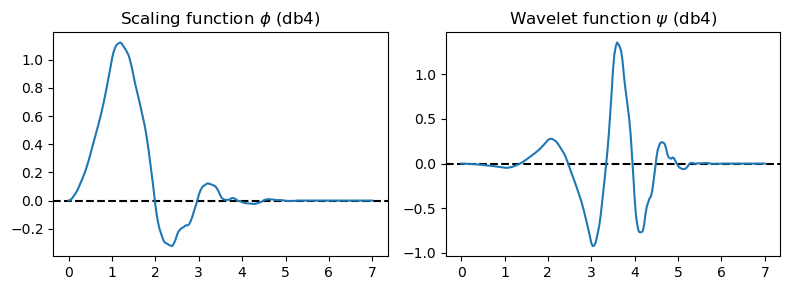

In [23]:
# NOTHING TO DO, JUST RUN THE CELL
wavelet = pywt.Wavelet("db4")
phi, psi, x_grid = wavelet.wavefun(level=5)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].axhline(0, ls='--', color="k")
axes[0].plot(x_grid, phi)
axes[0].set_title(r"Scaling function $\phi$ (db4)")
axes[1].axhline(0, ls='--', color="k")
axes[1].plot(x_grid, psi)
axes[1].set_title(r"Wavelet function $\psi$ (db4)")
plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h3>Task B.4: The orthonormal Daubechies wavelets</h3>
    To obtain an orthonormal basis of <b>Daubechies</b> wavelets, we dilate and translate the wavelet/scaling functions with values $a = 2^j$ and $b = k \cdot 2^j$, for integers $j, k$.
<br>
    Use the following wavelet and scaling functions (interpolated) to produce new orthonormal functions (at least 2 new ones). Verify they are actually orthonormal computing their inner product.
</ div>

Inner products:
<mother_0, mother_0> = +1.0000
<mother_1, mother_1> = +1.0000
<father_0, father_0> = +1.0000
<mother_0, mother_1> = -0.0000
<mother_0, father_0> = +0.0000


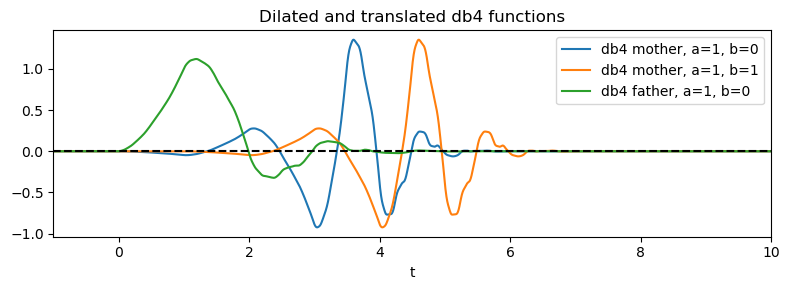

In [24]:
from scipy.interpolate import interp1d

# Sample db4's mother/father functions on a fine grid, to facilitate interpolation
db4 = pywt.Wavelet("db4")
phi_samples, psi_samples, x_grid = db4.wavefun(level=5)

# Wrap them as callable interpolants. Outside the support, return 0.
phi_interp = interp1d(x_grid, phi_samples, kind="cubic", bounds_error=False, fill_value=0.0)
psi_interp = interp1d(x_grid, psi_samples, kind="cubic", bounds_error=False, fill_value=0.0)

def db4_father(t, scale, translation):
    """Dilated, translated db4 scaling function."""
    return scale ** -0.5 * phi_interp((t - translation) / scale)

def db4_mother(t, scale, translation):
    """Dilated, translated db4 wavelet."""
    return scale ** -0.5 * psi_interp((t - translation) / scale)

# YOUR CODE HERE

# Fine grid for numerical integration
t_db4 = np.linspace(-2.0, 20.0, 10000)
dt_db4 = t_db4[1] - t_db4[0]

# Dyadic scale and translations: a = 2^j, b = k * 2^j
j = 0
scale = 2 ** j

f1 = db4_mother(t_db4, scale=scale, translation=0 * scale)
f2 = db4_mother(t_db4, scale=scale, translation=1 * scale)
f3 = db4_father(t_db4, scale=scale, translation=0 * scale)

print("Inner products:")
print(f"<mother_0, mother_0> = {inner_product(f1, f1, dt_db4):+.4f}")
print(f"<mother_1, mother_1> = {inner_product(f2, f2, dt_db4):+.4f}")
print(f"<father_0, father_0> = {inner_product(f3, f3, dt_db4):+.4f}")
print(f"<mother_0, mother_1> = {inner_product(f1, f2, dt_db4):+.4f}")
print(f"<mother_0, father_0> = {inner_product(f1, f3, dt_db4):+.4f}")

plt.figure(figsize=(8, 3))
plt.plot(t_db4, f1, label="db4 mother, a=1, b=0")
plt.plot(t_db4, f2, label="db4 mother, a=1, b=1")
plt.plot(t_db4, f3, label="db4 father, a=1, b=0")
plt.axhline(0, ls="--", color="k")
plt.xlim(-1, 10)
plt.xlabel("t")
plt.title("Dilated and translated db4 functions")
plt.legend()
plt.tight_layout()
plt.show()

## The 2D basis

For 2D signals (images), the basis is built from the 1D one by taking outer products. Each combination of $\phi$ or $\psi$ along the $x$ axis with $\phi$ or $\psi$ along the $y$ axis gives one of the four 2D basis functions:

- $\phi(x)\phi(y)$ — smooth in both directions (the "LL" sub-band).
- $\phi(x)\psi(y)$ — smooth horizontally, oscillating (mainly) vertically: detects horizontal edges (LH).
- $\psi(x)\phi(y)$ — oscillating (mainly) horizontally, smooth vertically: detects vertical edges (HL).
- $\psi(x)\psi(y)$ — oscillating in both directions: detects diagonal/corner detail (HH).

These four functions, together with their dilations and translations, span the 2D wavelet basis. The heatmaps below plot them.

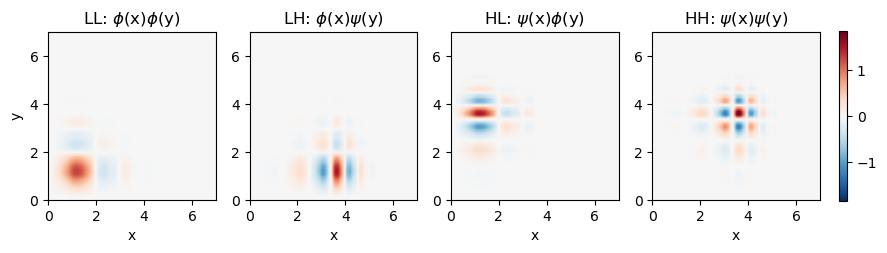

In [25]:
# NOTHING TO DO HERE, JUST RUN THE CODE
LL = np.outer(phi, phi)
LH = np.outer(phi, psi)
HL = np.outer(psi, phi)
HH = np.outer(psi, psi)

vmax = max(np.abs(arr).max() for arr in (LL, LH, HL, HH))
extent = [x_grid[0], x_grid[-1], x_grid[0], x_grid[-1]]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes[0].set_ylabel('y')
for ax, arr, title in zip(axes,
                          [LL, LH, HL, HH],
                          [r"LL: $\phi$(x)$\phi$(y)", r"LH: $\phi$(x)$\psi$(y)",
                           r"HL: $\psi$(x)$\phi$(y)", r"HH: $\psi$(x)$\psi$(y)"]):
    im = ax.imshow(arr, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   extent=extent, origin="lower")
    ax.set_title(title)
    ax.set_xlabel('x')

fig.colorbar(im, ax=axes, shrink=0.55, pad=0.02)
plt.show()

# Decomposing the image

In the following cells, we decompose an image using Fourier and wavelet transformations. We will see how the different compressions lead to different types of errors in the image. Then we will see the effects of tempering the highest coefficients from the two decompositions.

Image shape: (512, 768), 393216 pixels


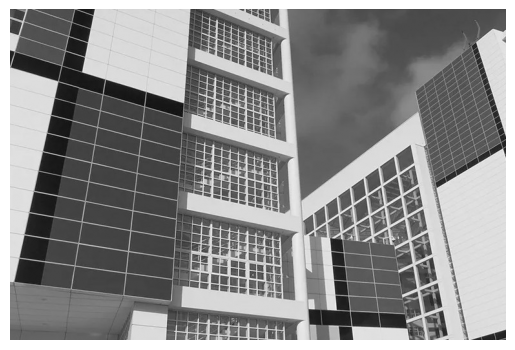

In [26]:
image = np.array(Image.open("mondrian.jpg").convert("L")) / 255.0
print(f"Image shape: {image.shape}, {np.prod(image.shape)} pixels")
plt.imshow(image,cmap='gray')
plt.axis("off")
plt.show()

In [27]:
# NOTHING TO DO HERE, JUST RUN THE CODE
fourier_coeffs = np.fft.fft2(image)
wavelet_coeffs = pywt.wavedec2(image, wavelet="db4", level=3)

# Pack the wavelet decomposition into a 2D array (the nested-quadrant layout).
wavelet_layout, wavelet_slices = pywt.coeffs_to_array(wavelet_coeffs)

print(f"Fourier coefficients: shape {fourier_coeffs.shape}, "
      f"{fourier_coeffs.size} complex values")
print(f"Wavelet coefficients (as 2D layout): shape {wavelet_layout.shape}, "
      f"{wavelet_layout.size} real values")

Fourier coefficients: shape (512, 768), 393216 complex values
Wavelet coefficients (as 2D layout): shape (532, 788), 419216 real values


In [28]:
# NOTHING TO DO HERE, JUST RUN THE CODE
def keep_largest(values, k):
    """Return a copy of `values` with all but the K largest-magnitude entries set to zero."""
    out = np.zeros_like(values)
    flat_values = values.ravel()
    threshold_idx = np.argpartition(np.abs(flat_values), -k)[-k:]
    out.flat[threshold_idx] = flat_values[threshold_idx]
    return out

def reconstruct_fourier(coeffs, k):
    truncated = keep_largest(coeffs, k)
    return np.real(np.fft.ifft2(truncated))

def reconstruct_wavelet(coeffs, k):
    flat, slices = pywt.coeffs_to_array(coeffs)
    flat_truncated = keep_largest(flat, k)
    coeffs_truncated = pywt.array_to_coeffs(flat_truncated, slices, output_format="wavedec2")
    return pywt.waverec2(coeffs_truncated, wavelet="db4")

# Visualizing and evaluating compression

Below we sweep $K$ as a fraction of the total number of coefficients, reconstruct under both bases, and compare. The metric is **PSNR**, [peak signal-to-noise ratio](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio), a standard image-quality metric.

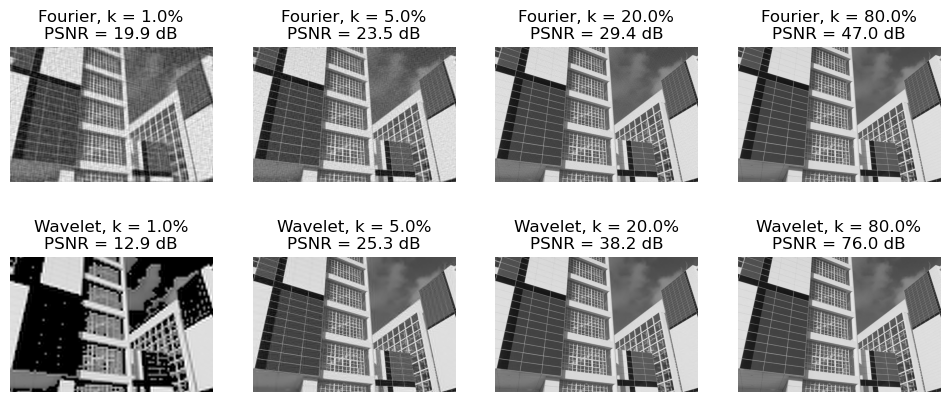

In [29]:
# NOTHING TO DO HERE, JUST RUN THE CODE
def psnr(reference, candidate):
    """Peak signal-to-noise ratio in dB. Both inputs in [0, 1]."""
    mse = np.mean((reference - candidate) ** 2)
    if mse <= 0:
        return float("inf")
    return - 10.0 * np.log10(mse) # here we now the peak is 1


fractions = [0.01, 0.05, 0.20, 0.80]
fig, axes = plt.subplots(2, len(fractions), figsize=(3 * len(fractions), 5))

for col, frac in enumerate(fractions):
    k_fft = max(1, int(frac * fourier_coeffs.size))
    k_wav = max(1, int(frac * wavelet_layout.size))

    recon_fft = reconstruct_fourier(fourier_coeffs, k_fft)
    recon_wav = reconstruct_wavelet(wavelet_coeffs, k_wav)
    
    axes[0, col].imshow(recon_fft, cmap="gray",vmin=0,vmax=1)
    axes[0, col].set_title(f"Fourier, k = {frac*100:.1f}%\nPSNR = {psnr(image, recon_fft):.1f} dB")
    axes[0, col].axis("off")

    axes[1, col].imshow(recon_wav, cmap="gray",vmin=0,vmax=1)
    axes[1, col].set_title(f"Wavelet, k = {frac*100:.1f}%\nPSNR = {psnr(image, recon_wav):.1f} dB")
    axes[1, col].axis("off")

plt.show()

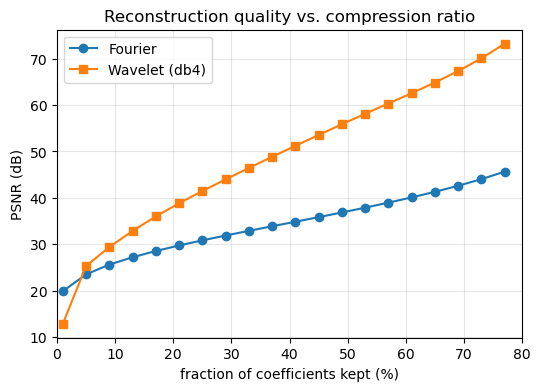

In [30]:
# NOTHING TO DO HERE, JUST RUN THE CODE
fractions_curve = np.linspace(0.01, .80, 80)[::4]
psnr_fft, psnr_wav = [], []

for frac in fractions_curve:
    k_fft = max(1, int(frac * fourier_coeffs.size))
    k_wav = max(1, int(frac * wavelet_layout.size))
    psnr_fft.append(psnr(image, reconstruct_fourier(fourier_coeffs, k_fft)))
    psnr_wav.append(psnr(image, reconstruct_wavelet(wavelet_coeffs, k_wav)))

plt.figure(figsize=(6, 4))
plt.plot(fractions_curve * 100, psnr_fft, "o-", label="Fourier")
plt.plot(fractions_curve * 100, psnr_wav, "s-", label="Wavelet (db4)")
plt.xlabel("fraction of coefficients kept (%)")
plt.ylabel("PSNR (dB)")
plt.title("Reconstruction quality vs. compression ratio")
plt.xlim(0,80)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-warning">
    <h3>Question B.5a: compression degradation</h3>
    The quality of the reconstructed image is poor when keeping the largest 1% of the coefficients, but the reconstructions look very different. Why? How is this related to the Heisenberg principle we saw in Part A?  
</ div>

<div class="alert alert-warning">
    <h3>Question B.5b: coefficient corruption</h3>
    When compressing the image, we removed the smallest coefficients. The following code lets you corrupt single coefficients, and corrupting the largest ones leads to major changes in the image. These are different errors from the ones we saw in compression. Play with them by modifying <code>rank</code> and <code>rescaling</code>.
    <ol>
        <li>What happens with the Fourier-encoded image when modifying the largest rank?</li>
        <li>What happens when modifying smaller coefficients (higher rank)? Are the errors similar?</li>
    </ol>
</ div>

**Answers here**

In [31]:
# Pick the k-th largest coefficient and multiply it by `rescaling`.
# When changing `rank` (0 = largest, 1 = second largest, ...),
# a larger rank needs a larger rescaling to make visible changes.

rank = 3
rescaling = 1e2

In [32]:
# Fourier

# argsort is ascending, so [::-1] gives largest-first; take the rank-th entry.
fft_ranked_flat = np.argsort(np.abs(fourier_coeffs), axis=None)[::-1]
fft_idx = np.unravel_index(fft_ranked_flat[rank], fourier_coeffs.shape)
print(f"Fourier rank {rank}: index {fft_idx}, "
      f"|value| = {abs(fourier_coeffs[fft_idx]):.2e}")

# Modify the chosen coefficient and its conjugate-symmetric partner so the inverse transform stays real.
fourier_corrupted = fourier_coeffs.copy()
sym_idx = (-fft_idx[0] % fourier_coeffs.shape[0],
           -fft_idx[1] % fourier_coeffs.shape[1])
fourier_corrupted[fft_idx] *= rescaling
fourier_corrupted[sym_idx] *= rescaling

recon_fft_corrupted = np.real(np.fft.ifft2(fourier_corrupted))

Fourier rank 3: index (511, 1), |value| = 1.68e+04


In [33]:
# Wavelet
wav_ranked_flat = np.argsort(np.abs(wavelet_layout), axis=None)[::-1]
wav_idx = np.unravel_index(wav_ranked_flat[rank], wavelet_layout.shape)
print(f"Wavelet rank {rank}: index {wav_idx}, "
      f"|value| = {abs(wavelet_layout[wav_idx]):.2e}")

wavelet_layout_corrupted = wavelet_layout.copy()
wavelet_layout_corrupted[wav_idx] *= rescaling
wavelet_corrupted = pywt.array_to_coeffs(wavelet_layout_corrupted,
                                         wavelet_slices,
                                         output_format="wavedec2")

recon_wav_corrupted = pywt.waverec2(wavelet_corrupted, wavelet="db4")

Wavelet rank 3: index (49, 6), |value| = 7.88e+00


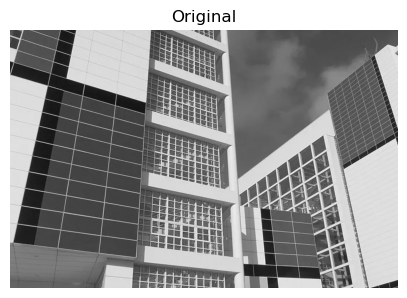

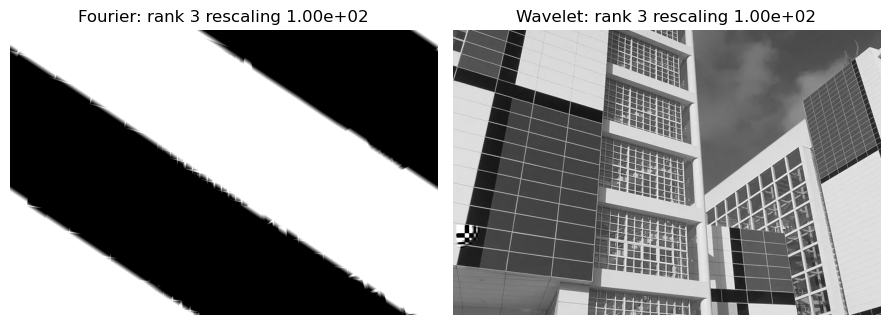

In [34]:
# Plot 
plt.figure(figsize=(5,4))
plt.imshow(image, cmap="gray", vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(recon_fft_corrupted, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Fourier: rank {rank} rescaling {rescaling:.2e}")
axes[0].axis("off")

axes[1].imshow(recon_wav_corrupted, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Wavelet: rank {rank} rescaling {rescaling:.2e}")
axes[1].axis("off")

plt.tight_layout()
plt.show()